# intial packages, settings

In [ ]:
# import packages
import os
from tifffile import TiffFile
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import cupy as cp
import pickle
import types
import os
# from concurrent.futures import ThreadPoolExecutor  
# from multiprocessing import Pool 
import seaborn as sns
import scanpy as sc

# settings
directory = '../raw_data/' # filesep at end


In [ ]:

# get filenames
filenames = os.listdir(directory)
filenames = [x for x in filenames if x.endswith('.tif')] # take only filenames with .tifs
filenames = sorted(filenames) # sort filenames alphabetically

filenames

['SLIDE-0265_0.0.2_R000_DAPI_F.tif',
 'SLIDE-0265_0.0.2_R000_DAPI_F_Tiled.tif',
 'SLIDE-0265_1.0.1_R000_20X_VHE_F.tif',
 'SLIDE-0265_1.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_Cy3_MSN-IIry-555_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_Cy5_TNC-IIry-647_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_Cy7_uPAR-IIry_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_FITC_PanCK-A1E1-AF488-2_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_10.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_10.0.4_R000_Cy3_PD1-EPR48772-555_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_10.0.4_R000_Cy5_YAP-D8H1X-647_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_10.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0265_10.0.4_R000_FITC_CD31-89C2-488_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_11.0.1_R000_DAPI_AF_F.ome.tif',
 'SLIDE-0265_11.0.4_R000_Cy3_GZMB-D6E9W-AF555_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_11.0.4_R000_Cy5_CD56-E7X9M-AF647_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_11.0.4_R000_DAPI__FINAL_F.ome.tif',
 'SLIDE-0

# obtain all tif filenames, in sorted order

In [ ]:
# get the 'number codes'
number_codes = [x.split('_')[1] for x in filenames]

number_codes

['7.0.4',
 '6.0.4',
 '11.0.4',
 '5.0.1',
 '7.0.1',
 '0.0.2',
 '5.0.4',
 '8.0.4',
 '5.0.4',
 '15.0.4',
 '2.0.4',
 '12.0.4',
 '1.0.1',
 '14.0.4',
 '9.0.1',
 '13.0.4',
 '15.0.4',
 '8.0.4',
 '8.0.4',
 '3.0.4',
 '9.0.4',
 '15.0.1',
 '7.0.4',
 '14.0.4',
 '11.0.4',
 '15.0.4',
 '2.0.4',
 '6.0.4',
 '11.0.4',
 '10.0.1',
 '11.0.1',
 '12.0.4',
 '14.0.4',
 '13.0.1',
 '12.0.1',
 '7.0.4',
 '10.0.4',
 '1.0.4',
 '8.0.1',
 '1.0.1',
 '4.0.1',
 '13.0.4',
 '5.0.4',
 '2.0.4',
 '0.0.2',
 '8.0.4',
 '4.0.4',
 '9.0.4',
 '14.0.4',
 '1.0.4',
 '10.0.4',
 '1.0.4',
 '2.0.1',
 '14.0.4',
 '6.0.4',
 '3.0.4',
 '14.0.1',
 '12.0.4',
 '15.0.4',
 '12.0.4',
 '10.0.4',
 '10.0.4',
 '5.0.4',
 '4.0.4',
 '4.0.4',
 '13.0.4',
 '9.0.4',
 '7.0.4',
 '6.0.4',
 '11.0.4',
 '1.0.4',
 '3.0.4',
 '4.0.4',
 '3.0.4',
 '4.0.4',
 '2.0.4',
 '6.0.1',
 '2.0.4',
 '7.0.4',
 '3.0.1',
 '1.0.4',
 '3.0.4',
 '9.0.4']

In [ ]:
# print number_codes
number_codes

['7.0.4',
 '6.0.4',
 '11.0.4',
 '5.0.1',
 '7.0.1',
 '0.0.2',
 '5.0.4',
 '8.0.4',
 '5.0.4',
 '15.0.4',
 '2.0.4',
 '12.0.4',
 '1.0.1',
 '14.0.4',
 '9.0.1',
 '13.0.4',
 '15.0.4',
 '8.0.4',
 '8.0.4',
 '3.0.4',
 '9.0.4',
 '15.0.1',
 '7.0.4',
 '14.0.4',
 '11.0.4',
 '15.0.4',
 '2.0.4',
 '6.0.4',
 '11.0.4',
 '10.0.1',
 '11.0.1',
 '12.0.4',
 '14.0.4',
 '13.0.1',
 '12.0.1',
 '7.0.4',
 '10.0.4',
 '1.0.4',
 '8.0.1',
 '1.0.1',
 '4.0.1',
 '13.0.4',
 '5.0.4',
 '2.0.4',
 '0.0.2',
 '8.0.4',
 '4.0.4',
 '9.0.4',
 '14.0.4',
 '1.0.4',
 '10.0.4',
 '1.0.4',
 '2.0.1',
 '14.0.4',
 '6.0.4',
 '3.0.4',
 '14.0.1',
 '12.0.4',
 '15.0.4',
 '12.0.4',
 '10.0.4',
 '10.0.4',
 '5.0.4',
 '4.0.4',
 '4.0.4',
 '13.0.4',
 '9.0.4',
 '7.0.4',
 '6.0.4',
 '11.0.4',
 '1.0.4',
 '3.0.4',
 '4.0.4',
 '3.0.4',
 '4.0.4',
 '2.0.4',
 '6.0.1',
 '2.0.4',
 '7.0.4',
 '3.0.1',
 '1.0.4',
 '3.0.4',
 '9.0.4']

In [ ]:
# convert number_codes, which is a list of strings, to numbers, whole point being to sort on the numbers
number_codes_converted = [ 1000000*float(x.split('.')[0]) + 1000*float(x.split('.')[1]) + float(x.split('.')[2]) for x in number_codes]

combined = list(zip(filenames,number_codes_converted))
combined_sorted = sorted(combined, key=lambda x: x[1])

filenames_sorted,number_codes_converted_sorted = zip(*combined_sorted)
print(number_codes_converted_sorted)
print(filenames_sorted)


(2.0, 2.0, 1000001.0, 1000001.0, 1000004.0, 1000004.0, 1000004.0, 1000004.0, 1000004.0, 2000001.0, 2000004.0, 2000004.0, 2000004.0, 2000004.0, 2000004.0, 3000001.0, 3000004.0, 3000004.0, 3000004.0, 3000004.0, 3000004.0, 4000001.0, 4000004.0, 4000004.0, 4000004.0, 4000004.0, 4000004.0, 5000001.0, 5000004.0, 5000004.0, 5000004.0, 5000004.0, 6000001.0, 6000004.0, 6000004.0, 6000004.0, 6000004.0, 7000001.0, 7000004.0, 7000004.0, 7000004.0, 7000004.0, 7000004.0, 8000001.0, 8000004.0, 8000004.0, 8000004.0, 8000004.0, 9000001.0, 9000004.0, 9000004.0, 9000004.0, 9000004.0, 10000001.0, 10000004.0, 10000004.0, 10000004.0, 10000004.0, 11000001.0, 11000004.0, 11000004.0, 11000004.0, 11000004.0, 12000001.0, 12000004.0, 12000004.0, 12000004.0, 12000004.0, 13000001.0, 13000004.0, 13000004.0, 13000004.0, 14000001.0, 14000004.0, 14000004.0, 14000004.0, 14000004.0, 14000004.0, 15000001.0, 15000004.0, 15000004.0, 15000004.0, 15000004.0)
('SLIDE-0265_0.0.2_R000_DAPI_F.tif', 'SLIDE-0265_0.0.2_R000_DAPI_F_T

In [ ]:
# show the middle number does not contain any information
print(set([float(x.split('.')[1]) for x in number_codes]))

# unique values in the last number of the 'number_code"
set([float(x.split('.')[2]) for x in number_codes])

{0.0}


{1.0, 2.0, 4.0}

In [ ]:
# print all filenames, in 'sorted' order
[print(f"{number_codes_converted_sorted[x]}  {filenames_sorted[x]}") for x in range(len(number_codes))]

2.0  SLIDE-0265_0.0.2_R000_DAPI_F.tif
2.0  SLIDE-0265_0.0.2_R000_DAPI_F_Tiled.tif
1000001.0  SLIDE-0265_1.0.1_R000_DAPI_AF_F.ome.tif
1000001.0  SLIDE-0265_1.0.1_R000_20X_VHE_F.tif
1000004.0  SLIDE-0265_1.0.4_R000_Cy3_MSN-IIry-555_FINAL_AFR_F.ome.tif
1000004.0  SLIDE-0265_1.0.4_R000_Cy7_uPAR-IIry_FINAL_AFR_F.ome.tif
1000004.0  SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif
1000004.0  SLIDE-0265_1.0.4_R000_FITC_PanCK-A1E1-AF488-2_FINAL_AFR_F.ome.tif
1000004.0  SLIDE-0265_1.0.4_R000_Cy5_TNC-IIry-647_FINAL_AFR_F.ome.tif
2000001.0  SLIDE-0265_2.0.1_R000_DAPI_AF_F.ome.tif
2000004.0  SLIDE-0265_2.0.4_R000_DAPI__FINAL_F.ome.tif
2000004.0  SLIDE-0265_2.0.4_R000_Cy7_VIM-D21H3-AF750_FINAL_AFR_F.ome.tif
2000004.0  SLIDE-0265_2.0.4_R000_Cy5_P16INK4A-EPR1473-647_FINAL_AFR_F.ome.tif
2000004.0  SLIDE-0265_2.0.4_R000_FITC_KRT17-EP1623-488_FINAL_AFR_F.ome.tif
2000004.0  SLIDE-0265_2.0.4_R000_Cy3_Arg1-D4E3M-555_FINAL_AFR_F.ome.tif
3000001.0  SLIDE-0265_3.0.1_R000_DAPI_AF_F.ome.tif
3000004.0  SLIDE-0265_3.0.

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
# printing filenames in sorted order, just without my number codes
[print(x) for x in filenames_sorted]

SLIDE-0265_0.0.2_R000_DAPI_F.tif
SLIDE-0265_0.0.2_R000_DAPI_F_Tiled.tif
SLIDE-0265_1.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_1.0.1_R000_20X_VHE_F.tif
SLIDE-0265_1.0.4_R000_Cy3_MSN-IIry-555_FINAL_AFR_F.ome.tif
SLIDE-0265_1.0.4_R000_Cy7_uPAR-IIry_FINAL_AFR_F.ome.tif
SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_1.0.4_R000_FITC_PanCK-A1E1-AF488-2_FINAL_AFR_F.ome.tif
SLIDE-0265_1.0.4_R000_Cy5_TNC-IIry-647_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_2.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_2.0.4_R000_Cy7_VIM-D21H3-AF750_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.4_R000_Cy5_P16INK4A-EPR1473-647_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.4_R000_FITC_KRT17-EP1623-488_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.4_R000_Cy3_Arg1-D4E3M-555_FINAL_AFR_F.ome.tif
SLIDE-0265_3.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_3.0.4_R000_FITC_HMAG1-AF488-EPR7839_FINAL_AFR_F.ome.tif
SLIDE-0265_3.0.4_R000_Cy3_KI67-D3B5-AF555_FINAL_AFR_F.ome.tif
SLIDE-0265_3.0.4_R000_Cy5_p53-DO-7-AF647_FINAL_AFR_F.ome.tif


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
# print all filenames that have been sorted, that are non-dapi

[print(x) for x in filenames_sorted if 'dapi' not in x.lower()]

SLIDE-0265_1.0.1_R000_20X_VHE_F.tif
SLIDE-0265_1.0.4_R000_Cy3_MSN-IIry-555_FINAL_AFR_F.ome.tif
SLIDE-0265_1.0.4_R000_Cy7_uPAR-IIry_FINAL_AFR_F.ome.tif
SLIDE-0265_1.0.4_R000_FITC_PanCK-A1E1-AF488-2_FINAL_AFR_F.ome.tif
SLIDE-0265_1.0.4_R000_Cy5_TNC-IIry-647_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.4_R000_Cy7_VIM-D21H3-AF750_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.4_R000_Cy5_P16INK4A-EPR1473-647_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.4_R000_FITC_KRT17-EP1623-488_FINAL_AFR_F.ome.tif
SLIDE-0265_2.0.4_R000_Cy3_Arg1-D4E3M-555_FINAL_AFR_F.ome.tif
SLIDE-0265_3.0.4_R000_FITC_HMAG1-AF488-EPR7839_FINAL_AFR_F.ome.tif
SLIDE-0265_3.0.4_R000_Cy3_KI67-D3B5-AF555_FINAL_AFR_F.ome.tif
SLIDE-0265_3.0.4_R000_Cy5_p53-DO-7-AF647_FINAL_AFR_F.ome.tif
SLIDE-0265_3.0.4_R000_Cy7_CC3-D3E9-AF750_FINAL_AFR_F.ome.tif
SLIDE-0265_4.0.4_R000_FITC_aSMA-D4K9N-AF488_FINAL_AFR_F.ome.tif
SLIDE-0265_4.0.4_R000_Cy3_CD68-D4B9C-AF555_FINAL_AFR_F.ome.tif
SLIDE-0265_4.0.4_R000_Cy7_pSTAT1-58D6-AF750_FINAL_AFR_F.ome.tif
SLIDE-0265_4.0.4_R000_Cy5_p2

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
# remove variables

del combined, combined_sorted, filenames
del number_codes, number_codes_converted, number_codes_converted_sorted

# look thru filenames with DAPI

In [ ]:
[print(x) for x in filenames_sorted if 'DAPI' in x]

SLIDE-0265_0.0.2_R000_DAPI_F.tif
SLIDE-0265_0.0.2_R000_DAPI_F_Tiled.tif
SLIDE-0265_1.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_1.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_2.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_2.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_3.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_3.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_4.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_4.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_5.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_5.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_6.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_6.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_7.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_7.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_8.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_8.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_9.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_9.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_10.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_10.0.4_R000_DAPI__FINAL_F.ome.tif
SLIDE-0265_11.0.1_R000_DAPI_AF_F.ome.tif
SLIDE-0265_11.0.4_R000_DAPI__FINAL_F.ome.tif


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

# look for repeat markers

In [ ]:
filenames_sorted_nondapi = [x for x in filenames_sorted if 'dapi' not in x.lower()]

filenames_sorted_nondapi

['SLIDE-0265_1.0.1_R000_20X_VHE_F.tif',
 'SLIDE-0265_1.0.4_R000_Cy3_MSN-IIry-555_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_Cy7_uPAR-IIry_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_FITC_PanCK-A1E1-AF488-2_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_1.0.4_R000_Cy5_TNC-IIry-647_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_2.0.4_R000_Cy7_VIM-D21H3-AF750_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_2.0.4_R000_Cy5_P16INK4A-EPR1473-647_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_2.0.4_R000_FITC_KRT17-EP1623-488_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_2.0.4_R000_Cy3_Arg1-D4E3M-555_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_3.0.4_R000_FITC_HMAG1-AF488-EPR7839_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_3.0.4_R000_Cy3_KI67-D3B5-AF555_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_3.0.4_R000_Cy5_p53-DO-7-AF647_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_3.0.4_R000_Cy7_CC3-D3E9-AF750_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_4.0.4_R000_FITC_aSMA-D4K9N-AF488_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_4.0.4_R000_Cy3_CD68-D4B9C-AF555_FINAL_AFR_F.ome.tif',
 'SLIDE-0265_4.0.4_R000_Cy7_pSTA

In [ ]:
# check which filenames do not end in '_AFR_F.ome.tif'
[print(x) for x in filenames_sorted_nondapi if not x.endswith('_AFR_F.ome.tif')]

SLIDE-0265_1.0.1_R000_20X_VHE_F.tif


[None]

In [ ]:
# get markers

markers = ['_'.join(x.split('_')[4:]) for x in filenames_sorted_nondapi]
markers = sorted(markers)

markers

['Arg1-D4E3M-555_FINAL_AFR_F.ome.tif',
 'CC3-D3E9-AF750_FINAL_AFR_F.ome.tif',
 'CD11b-D6X1N-AF647_FINAL_AFR_F.ome.tif',
 'CD11c-D3V1E-AF555_FINAL_AFR_F.ome.tif',
 'CD163-D6U1J-488_FINAL_AFR_F.ome.tif',
 'CD20-EyB7T-555_FINAL_AFR_F.ome.tif',
 'CD31-89C2-488_FINAL_AFR_F.ome.tif',
 'CD3e-D7A6E-AF555_FINAL_AFR_F.ome.tif',
 'CD4-EPR6855-647_FINAL_AFR_F.ome.tif',
 'CD45-D9M8I-AF647_FINAL_AFR_F.ome.tif',
 'CD56-E7X9M-AF647_FINAL_AFR_F.ome.tif',
 'CD68-D4B9C-AF555_FINAL_AFR_F.ome.tif',
 'CD8a-D8A8Y-AF555_FINAL_AFR_F.ome.tif',
 'COL1A1-E8F4L-AF555_FINAL_AFR_F.ome.tif',
 'CryAB-NBPoly-AF750_FINAL_AFR_F.ome.tif',
 'EGFR-D38B1-555_FINAL_AFR_F.ome.tif',
 'Ecad-24E10-488_FINAL_AFR_F.ome.tif',
 'GZMB-D6E9W-AF555_FINAL_AFR_F.ome.tif',
 'Glut1-E4S6I-AF555_FINAL_AFR_F.ome.tif',
 'H3me3K9-EPR16601-488_FINAL_AFR_F.ome.tif',
 'HLA-DR-TAL1B5-AF488_FINAL_AFR_F.ome.tif',
 'HMAG1-AF488-EPR7839_FINAL_AFR_F.ome.tif',
 'HMGA2-D1A7-647_FINAL_AFR_F.ome.tif',
 'IBA1-E4O4W-488_FINAL_AFR_F.ome.tif',
 'IRF1-D5E4-647_FI

In [ ]:
markers_sub = [x.lower()[:6] for x in markers]

markers_sub

['arg1-d',
 'cc3-d3',
 'cd11b-',
 'cd11c-',
 'cd163-',
 'cd20-e',
 'cd31-8',
 'cd3e-d',
 'cd4-ep',
 'cd45-d',
 'cd56-e',
 'cd68-d',
 'cd8a-d',
 'col1a1',
 'cryab-',
 'egfr-d',
 'ecad-2',
 'gzmb-d',
 'glut1-',
 'h3me3k',
 'hla-dr',
 'hmag1-',
 'hmga2-',
 'iba1-e',
 'irf1-d',
 'ki67-d',
 'krt17-',
 'mhci-e',
 'mpo-e1',
 'msn-ii',
 'nak-at',
 'p16ink',
 'pd1-ep',
 'panck-',
 'podopl',
 'pselec',
 'sox2-2',
 'tnc-ii',
 'tubb3-',
 'vhe_f.',
 'vim-d2',
 'yap-d8',
 'asma-d',
 'b-cat-',
 'cgas-6',
 'p21-ep',
 'p53-do',
 'perk-d',
 'pstat1',
 'pstat3',
 'upar-i']

In [ ]:
if len(markers_sub) == len(set(markers_sub)):
    print('no repeat marker filenames detected')
else:
    print('UH OH, filenames with repeat markers detected')

no repeat marker filenames detected


# misc, can delete

In [ ]:
adata = sc.read('07_adata.h5ad')

In [ ]:
adata.obs

,core_id,cell_id,area,centroid_row_local,centroid_col_local,centroid_row_global,centroid_col_global,phenograph_cluster,censored_bcat,censored_Ecad,...,mpo_signature,endothelial_signature,stromal_signature,cell_type,pheno_per_core,cell_type_immune,krt17_pheno_positive,krt17_threshold_all_epi,krt17_threshold_panck_only,censored_KRT17
0_1,0,1,326.0,50.365031,4060.981595,499.365031,4909.981595,75,False,False,...,3.945707,3.706511,4.419833,undefined,0_34,other,False,False,False,False
0_2,0,2,496.0,82.040323,4022.814516,531.040323,4871.814516,75,False,False,...,3.953132,3.729954,4.438192,undefined,0_34,other,False,False,False,False
0_3,0,3,289.0,82.145329,4060.204152,531.145329,4909.204152,75,False,False,...,3.922141,3.709071,4.417025,undefined,0_34,other,False,False,False,False
0_4,0,4,214.0,131.056075,4036.345794,580.056075,4885.345794,75,False,False,...,4.198598,4.084424,4.541458,undefined,0_34,other,False,False,False,False
0_5,0,5,73.0,211.863014,3748.095890,660.863014,4597.095890,21,False,False,...,4.790170,4.541499,4.786204,epithelial_bcat,0_7,other,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67_17592,67,17592,528.0,6292.714015,3899.920455,52341.714015,66348.920455,24,False,False,...,5.316774,3.995444,5.540175,epithelial_panck,67_5,other,False,False,False,False
67_17593,67,17593,437.0,6293.050343,3968.233410,52342.050343,66417.233410,24,False,False,...,5.350263,4.069391,5.452968,epithelial_panck,67_5,other,False,False,False,False
67_17594,67,17594,148.0,6294.736486,3180.304054,52343.736486,65629.304054,16,False,False,...,6.639749,4.057847,5.525236,stromal,67_28,other,False,False,False,False
67_17595,67,17595,210.0,6295.071429,3740.161905,52344.071429,66189.161905,3,False,False,...,5.612854,3.736819,5.702007,stromal,67_22,other,False,False,False,False


In [ ]:
adata.obs['cell_type'].unique()

['undefined', 'epithelial_bcat', 'stromal', 'epithelial_panck', 'glut1_pos', 'immune']
Categories (6, object): ['epithelial_bcat', 'epithelial_panck', 'glut1_pos', 'immune', 'stromal', 'undefined']

In [ ]:
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix

mask = adata.obs['cell_type'].isin(['stromal', 'immune' , 'epithelial_bcat' , 'epithelial_panck'])
ad = adata[mask , :].copy()
radius = 60

ct = ad.obs['cell_type'].astype('category')  
codes = ct.cat.codes.to_numpy()                
categories = ct.cat.categories                
n_types = len(categories)       


coordinates = ad.obs[['centroid_row_global','centroid_col_global']].to_numpy()


tree = cKDTree(coordinates)
neighbors = tree.query_ball_point(coordinates, r=radius)
counts = [len(x) for x in neighbors]

n = coordinates.shape[0]

row_idx = []
col_idx = []

for i, nb in enumerate(neighbors):
    for j in nb:
        if j == i:
            continue  # optional: drop self
        row_idx.append(i)
        col_idx.append(j)
        
data = np.ones(len(row_idx), dtype=np.float32)
A = coo_matrix((data, (row_idx, col_idx)), shape=(n, n)).tocsr()

ct = ad.obs['cell_type'].astype('category')  
codes = ct.cat.codes.to_numpy()                
categories = ct.cat.categories              
n_types = len(categories)       


rows = np.arange(n)
T = coo_matrix(
    (np.ones(n, dtype=np.float32), (rows, codes)),
    shape=(n, n_types)
).tocsr()

# Perform the matrix multiplication to count cell types in each neighborhood
neighbor_counts = (A @ T).toarray()  # Convert to a dense array for easy inspection
row_sums = neighbor_counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0  # Avoid division by zero if there are no neighbors
neighbor_proportions = neighbor_counts / row_sums  # This is the composition

# Filter for neighborhoods with at least n neighbors
n = 5
counts = np.array(counts)
neighbor_proportions = neighbor_proportions[counts > n]

(array([2.88480e+04, 5.84720e+04, 1.24770e+05, 2.21050e+05, 2.90259e+05,
        2.64268e+05, 1.69458e+05, 8.35360e+04, 3.52310e+04, 1.39460e+04,
        7.70200e+03, 2.05600e+03, 7.85000e+02, 2.39000e+02, 6.00000e+01,
        2.20000e+01, 1.80000e+01, 9.00000e+00, 9.00000e+00, 4.00000e+00]),
 array([ 1. ,  3.1,  5.2,  7.3,  9.4, 11.5, 13.6, 15.7, 17.8, 19.9, 22. ,
        24.1, 26.2, 28.3, 30.4, 32.5, 34.6, 36.7, 38.8, 40.9, 43. ]),
 <BarContainer object of 20 artists>)

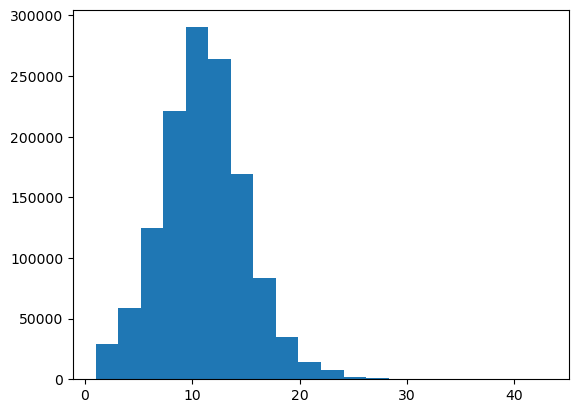

In [ ]:
plt.hist(counts, bins = 20)


In [ ]:
# apply clr transformation

def clr_transform(proportions, pseudocount=1e-6):
    """
    Perform centered log-ratio (CLR) transformation on the input proportions.
    Assumes proportions sum to 1 along each row (composition).
    
    :param proportions: A 2D numpy array where each row is a composition.
    :return: CLR transformed array (same shape as input).
    """
    
    # Add pseudocount
    proportions = proportions + pseudocount
    
    # Compute the geometric mean for each composition (row)
    geometric_mean = np.exp(np.mean(np.log(proportions), axis=1))  # Geometric mean for each row
    
    # CLR transformation: log(x_i) - log(g(x))
    clr_values = np.log(proportions) - np.log(geometric_mean[:, None])  # Subtract log(g(x)) from each log(x_i)
    
    return clr_values

neighbor_proportions_clr = clr_transform(neighbor_proportions)

In [ ]:
import cuml

def umap(
    X,
    n_neighbors = 30,
    min_dist = 0.05
):
    model = cuml.UMAP(
        min_dist=min_dist,
        spread=1,
        learning_rate=0.1,
        n_epochs=20000,
        n_neighbors = n_neighbors,
        verbose=True
    )
    X = cp.array(X)
    model.fit(X=X)
    X_umap = model.transform(X)
    return(X_umap.get())

def umap_2(
    X,
    n_neighbors = 30,
    min_dist = 0.05
):
    model = cuml.UMAP(
        min_dist=min_dist,
        spread=1,
        learning_rate=0.1,
        n_epochs=20000,
        n_neighbors = n_neighbors,
        verbose=True
    )
    X = cp.array(X)
    model.fit(X=X)
    X_umap = model.fit_transform(X)
    return(X_umap.get())


# subsample
n_rows = neighbor_proportions_clr.shape[0]
sample_size = int(n_rows * 0.5)  
random_indices = np.random.choice(n_rows, size=sample_size, replace=False)
sampled_rows = neighbor_proportions_clr[random_indices]

neighbor_proportions_clr_umap = umap_2(sampled_rows) # 10 min



[2025-11-14 06:22:57.216] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2025-11-14 06:22:57.219] [CUML] [debug] Computing KNN Graph
[2025-11-14 06:23:22.821] [CUML] [debug] Computing fuzzy simplicial set
[2025-11-14 06:32:21.650] [CUML] [debug] Computing KNN Graph
[2025-11-14 06:32:47.689] [CUML] [debug] Computing fuzzy simplicial set


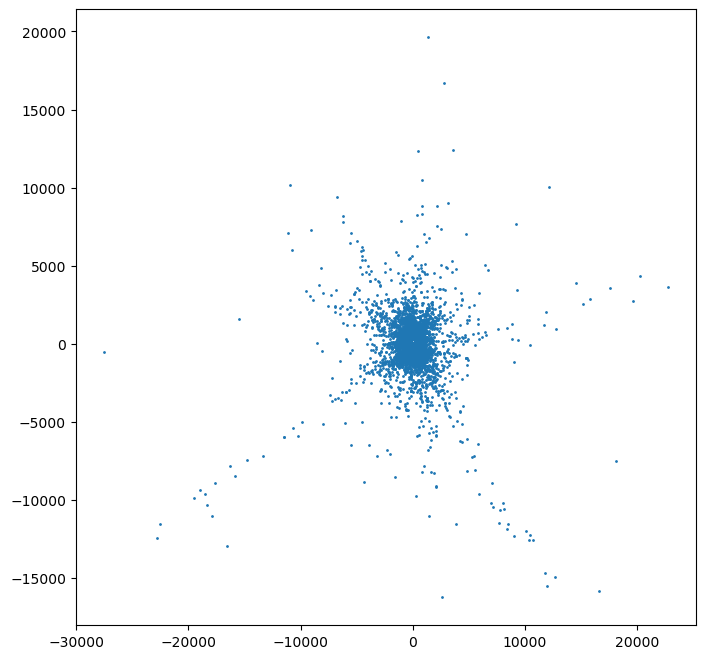

In [ ]:
x = neighbor_proportions_clr_umap[:,0]
y = neighbor_proportions_clr_umap[:,1]

_ , ax = plt.subplots(figsize = (8, 8))
ax.scatter(x,y, s = 1)
# ax.set_xticks([]); ax.set_yticks([])

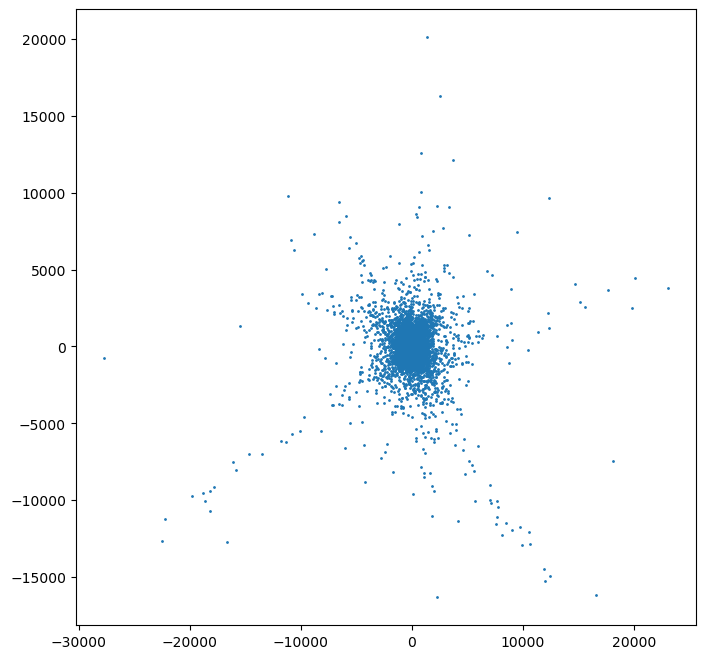

In [ ]:
def circular_jitter(x, y, radius=0.1):
    """
    Add circular jitter of maximum radius to points (x, y).
    Returns jittered x', y'.
    """
    n = len(x)

    # random angles
    theta = np.random.uniform(0, 2*np.pi, n)

    # random radii (with sqrt so distribution is uniform in circle)
    r = radius * np.sqrt(np.random.uniform(0, 1, n))

    # convert to dx, dy
    dx = r * np.cos(theta)
    dy = r * np.sin(theta)

    return x + dx, y + dy

x = neighbor_proportions_clr_umap[:,0]
y = neighbor_proportions_clr_umap[:,1]

x , y = circular_jitter(x , y , radius = 500)

_ , ax = plt.subplots(figsize = (8,8))
ax.scatter(x,y, s = 1)



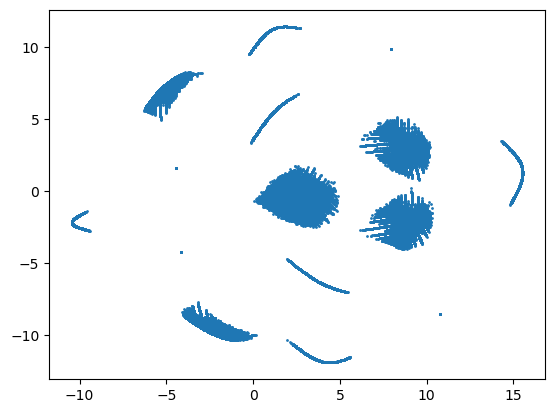

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)  # We only want the first 2 components
X_pca = pca.fit_transform(neighbor_proportions_clr)

x = X_pca[:,0]
y = X_pca[:,1]
_ , ax = plt.subplots()
ax.scatter(x,y, s = 1)

# Plot the first two principal components
# plt.figure(figsize=(8, 6))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], edgecolors='k', alpha=0.7)
# plt.title('PCA - First 2 Components')
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.grid(True)
# plt.show()

In [ ]:
neighbor_proportions_clr.shape

(1213422, 4)

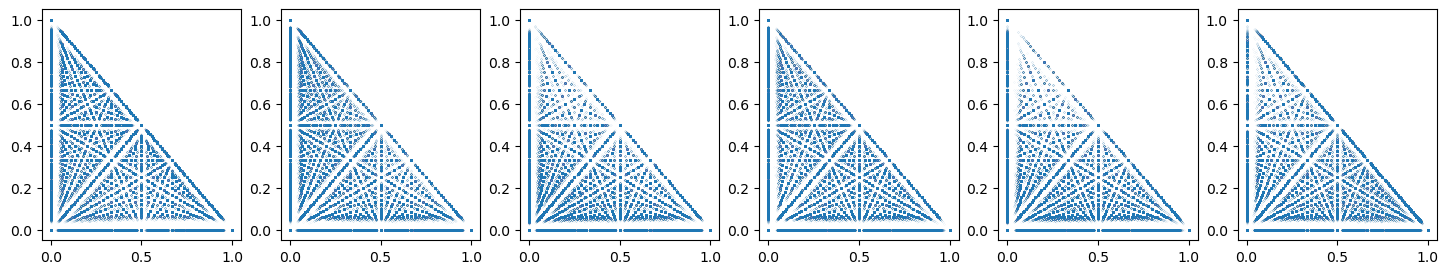

In [ ]:

_ , ax_grid = plt.subplots(1,6, figsize = (18,3))
counter = 0
for i in range(4):
    for j in range(i+1,4):
        ax = ax_grid[counter]
        x = neighbor_proportions[:,i]
        y = neighbor_proportions[:,j]
        ax.scatter(x , y , s = 0.001)
        
        counter += 1

del ax_grid, counter, i , j, ax , x , y


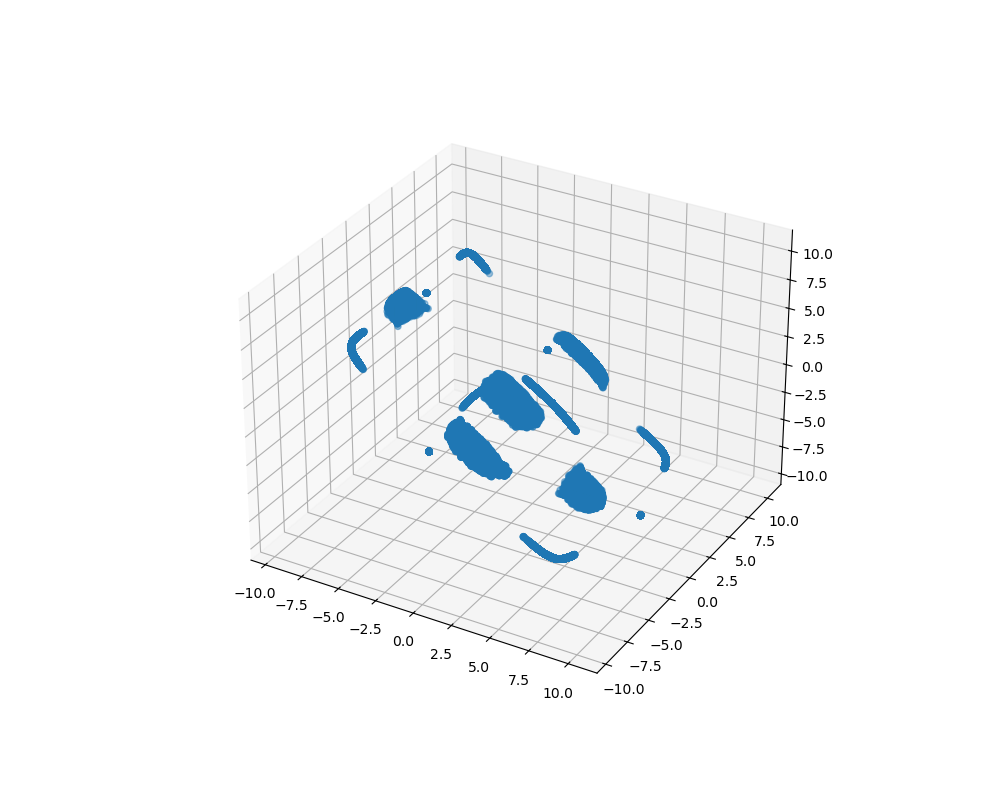

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

x = neighbor_proportions_clr[:,0]
y = neighbor_proportions_clr[:,1]
z = neighbor_proportions_clr[:,2]


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x,y,z)


In [ ]:
neighbor_proportions.shape

(815270, 3)

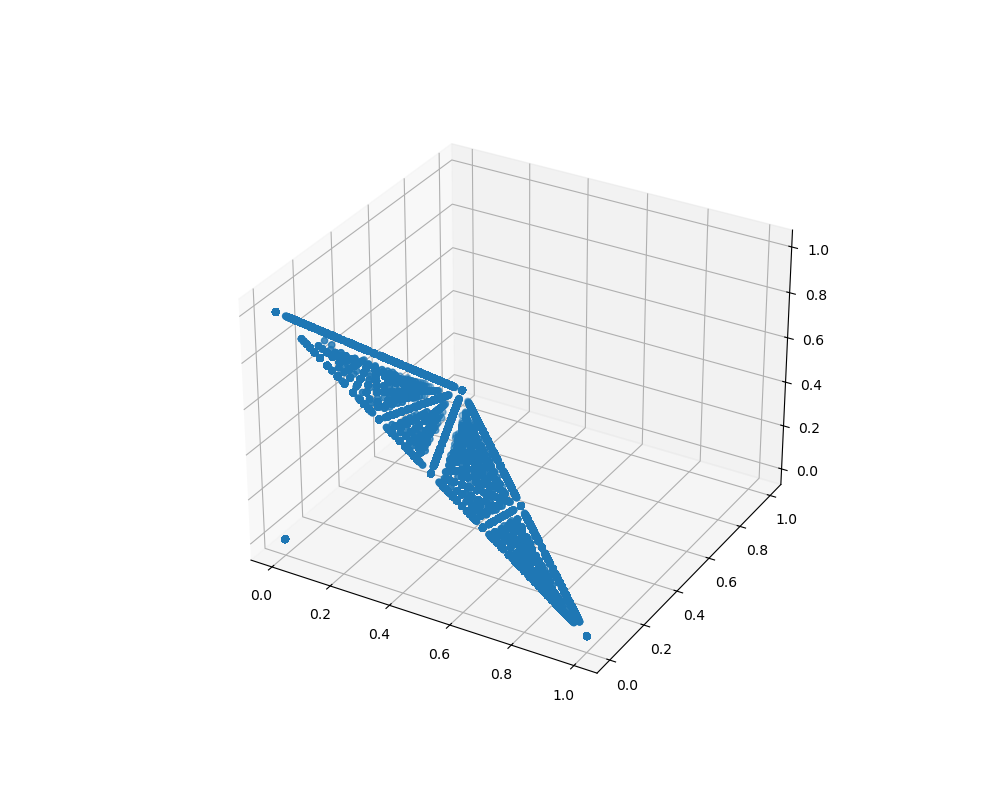

In [ ]:
%matplotlib widget 

from mpl_toolkits.mplot3d import Axes3D

x = neighbor_proportions[:,0]
y = neighbor_proportions[:,1]
z = neighbor_proportions[:,2]


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x,y,z)


In [ ]:
# apply clr transformation

def log_transform(proportions, pseudocount=1e-6):
    """
    Perform centered log-ratio (CLR) transformation on the input proportions.
    Assumes proportions sum to 1 along each row (composition).
    
    :param proportions: A 2D numpy array where each row is a composition.
    :return: CLR transformed array (same shape as input).
    """
    
    # Add pseudocount
    proportions = proportions + pseudocount
    
    # Compute the geometric mean for each composition (row)
    #geometric_mean = np.exp(np.mean(np.log(proportions), axis=1))  # Geometric mean for each row
    
    # CLR transformation: log(x_i) - log(g(x))
    log_values = np.log(proportions) #- np.log(geometric_mean[:, None])  # Subtract log(g(x)) from each log(x_i)
    
    return log_values

neighbor_proportions_log = log_transform(neighbor_proportions)


In [ ]:
import cuml

def umap(
    X,
    n_neighbors = 30,
    min_dist = 0.05
):
    model = cuml.UMAP(
        min_dist=min_dist,
        spread=1,
        learning_rate=0.1,
        n_epochs=20000,
        n_neighbors = n_neighbors,
        verbose=True
    )
    X = cp.array(X)
    model.fit(X=X)
    X_umap = model.transform(X)
    return(X_umap.get())

def umap_2(
    X,
    n_neighbors = 30,
    min_dist = 0.05
):
    model = cuml.UMAP(
        min_dist=min_dist,
        spread=1,
        learning_rate=0.1,
        n_epochs=20000,
        n_neighbors = n_neighbors,
        verbose=True
    )
    X = cp.array(X)
    model.fit(X=X)
    X_umap = model.fit_transform(X)
    return(X_umap.get())


# subsample
n_rows = neighbor_proportions_clr.shape[0]
sample_size = int(n_rows * 0.20)  
random_indices = np.random.choice(n_rows, size=sample_size, replace=False)
sampled_rows = neighbor_proportions_log[random_indices]

neighbor_proportions_clr_umap = umap_2(sampled_rows) # 10 min



## synthetic spatial data

In [ ]:
ct = ad.obs['cell_type'].astype('category')  


In [ ]:
type(ct)

pandas.core.series.Series

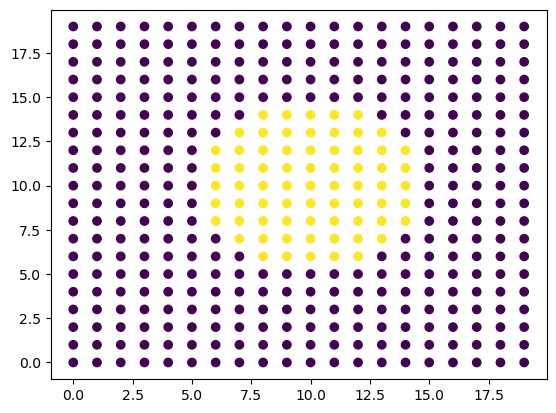

In [ ]:
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix

cell_types = []
coordinates = []
for i in range(20):
    for j in range(20):
        if (i-10)**2 + (j-10)**2 < 25:
            cell_types.append(1)
        else:
            cell_types.append(0)
            
        # coordinates = np.vstack((coordinates, np.array([i,j])))
        coordinates.append([i,j])
        
coordinates = np.array(coordinates)
cell_types = pd.Series(cell_types)

_ , ax = plt.subplots()
ax.scatter(coordinates[:,0],coordinates[:,1],c = cell_types)

del i,j,ax



In [ ]:
radius = 2.5
ct = cell_types.astype('category')  
codes = ct.cat.codes.to_numpy()                
categories = ct.cat.categories                
n_types = len(categories)       


tree = cKDTree(coordinates)
neighbors = tree.query_ball_point(coordinates, r=radius)
counts = [len(x) for x in neighbors]

n = coordinates.shape[0]

row_idx = []
col_idx = []

for i, nb in enumerate(neighbors):
    for j in nb:
        if j == i:
            continue  # optional: drop self
        row_idx.append(i)
        col_idx.append(j)
        
data = np.ones(len(row_idx), dtype=np.float32)
A = coo_matrix((data, (row_idx, col_idx)), shape=(n, n)).tocsr()

rows = np.arange(n)
T = coo_matrix(
    (np.ones(n, dtype=np.float32), (rows, codes)),
    shape=(n, n_types)
).tocsr()

# Perform the matrix multiplication to count cell types in each neighborhood
neighbor_counts = (A @ T).toarray()  # Convert to a dense array for easy inspection
row_sums = neighbor_counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0  # Avoid division by zero if there are no neighbors
neighbor_proportions = neighbor_counts / row_sums  # This is the composition

del ct, codes, categories, n_types, tree, neighbors, counts, n, row_idx, col_idx
del i, nb, j, data, A, rows, T, row_sums, neighbor_counts

In [ ]:
neighbor_proportions.shape

(400, 2)

In [ ]:
# apply clr transformation

def clr_transform(proportions, pseudocount=1e-6):
    """
    Perform centered log-ratio (CLR) transformation on the input proportions.
    Assumes proportions sum to 1 along each row (composition).
    
    :param proportions: A 2D numpy array where each row is a composition.
    :return: CLR transformed array (same shape as input).
    """
    
    # Add pseudocount
    proportions = proportions + pseudocount
    
    # Compute the geometric mean for each composition (row)
    geometric_mean = np.exp(np.mean(np.log(proportions), axis=1))  # Geometric mean for each row
    
    # CLR transformation: log(x_i) - log(g(x))
    clr_values = np.log(proportions) - np.log(geometric_mean[:, None])  # Subtract log(g(x)) from each log(x_i)
    
    return clr_values

neighbor_proportions_clr = clr_transform(neighbor_proportions)

In [ ]:
import cuml

def umap(
    X,
    n_neighbors = 30,
    min_dist = 0.05
):
    model = cuml.UMAP(
        min_dist=min_dist,
        spread=1,
        learning_rate=0.1,
        n_epochs=20000,
        n_neighbors = n_neighbors,
        verbose=True
    )
    X = cp.array(X)
    model.fit(X=X)
    X_umap = model.transform(X)
    return(X_umap.get())

def umap_2(
    X,
    n_neighbors = 30,
    min_dist = 0.05
):
    model = cuml.UMAP(
        min_dist=min_dist,
        spread=1,
        learning_rate=0.1,
        n_epochs=20000,
        n_neighbors = n_neighbors,
        verbose=True
    )
    X = cp.array(X)
    model.fit(X=X)
    X_umap = model.fit_transform(X)
    return(X_umap.get())


# subsample
n_rows = neighbor_proportions_clr.shape[0]
sample_size = int(n_rows * 0.50)  
random_indices = np.random.choice(n_rows, size=sample_size, replace=False)
sampled_rows = neighbor_proportions_clr[random_indices]

neighbor_proportions_clr_umap = umap_2(sampled_rows) # 10 min



AttributeError: module 'numba.cuda' has no attribute 'cudadrv'

In [ ]:
x = neighbor_proportions_clr_umap[:,0] + np.random.rand(neighbor_proportions_clr.shape[0])
y = neighbor_proportions_clr_umap[:,1] + np.random.rand(neighbor_proportions_clr.shape[0])

_ , ax = plt.subplots()
ax.scatter(x , y , s = 2)

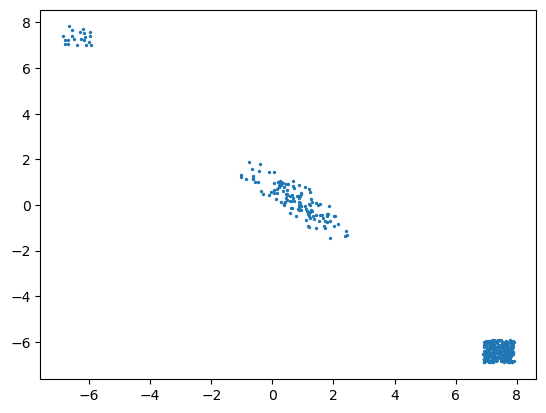

In [ ]:
x = neighbor_proportions_clr[:,0] + np.random.rand(neighbor_proportions_clr.shape[0])
y = neighbor_proportions_clr[:,1] + np.random.rand(neighbor_proportions_clr.shape[0])

_ , ax = plt.subplots()
ax.scatter(x , y , s = 2)

In [ ]:
x 